# Visualize ODF and sample discrete orientations using the hybridIA algorithm
* Contributor: Martin Diehl (https://martin-diehl.net)
* DAMASK version: 3.1.0

In [1]:
import damask
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['text.usetex'] = True # set to False if Latex is not installed

In [2]:
fname = 'ODF_experimental_cell.txt'
col = 'intensity'

In [3]:
tbl = damask.Table.load(fname)
try:
    weights = tbl.get(col)
except KeyError:
    print(f'column {col} not present in file {fname}')
print(damask.util.srepr(tbl.comments))

phi_1 fast, phi_2 slow
range(1.25,...,358.75;1.25,...,88.75;1.25,...,88.75)/deg
resolution 2.5 deg
cell centered


In [4]:
# from header
res = 2.5
limits = np.array([360,90,90])

In [5]:
# generate ODF discretization
N_samples = 4000

steps = (limits/res).astype(int)
phi = damask.grid_filters.coordinates0_point(steps,limits).reshape(-1,3,order='F')

In [6]:
# sample discrete orientations using hybridIA
sampled = damask.Rotation.from_ODF(weights,phi,shape=N_samples,degrees=True,rng_seed=202191102)
sampled_eu = sampled.as_Euler_angles(degrees=True)

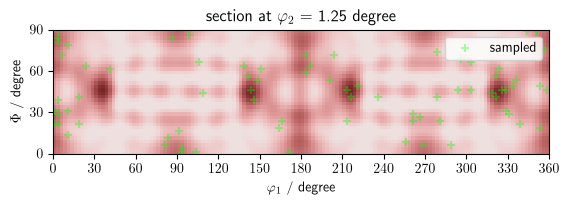

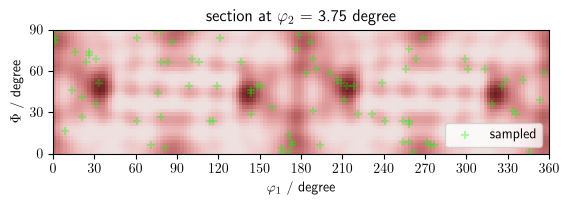

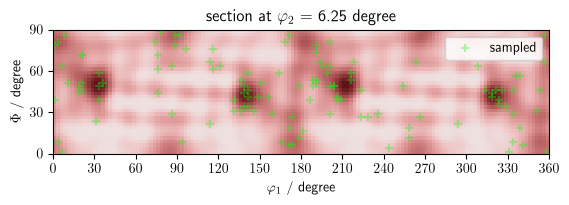

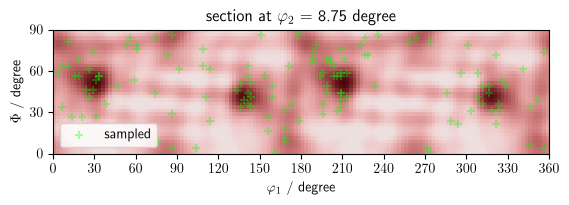

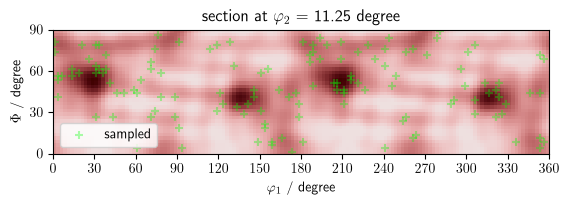

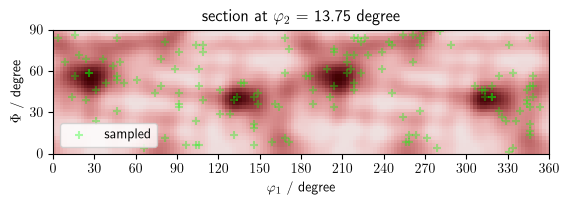

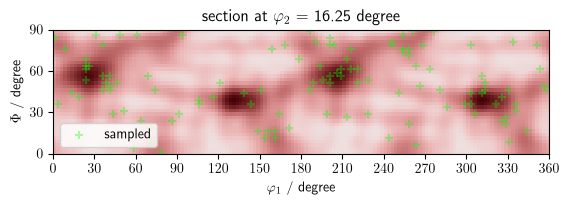

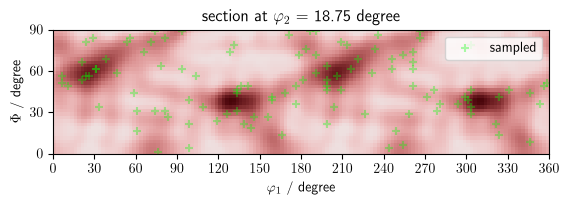

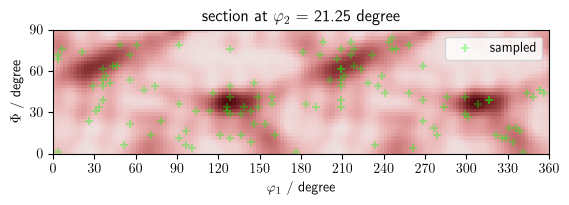

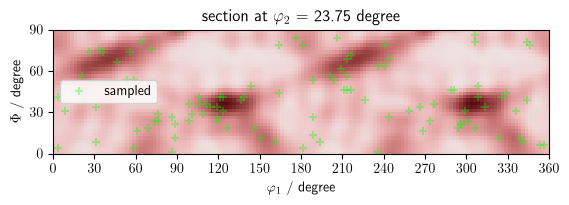

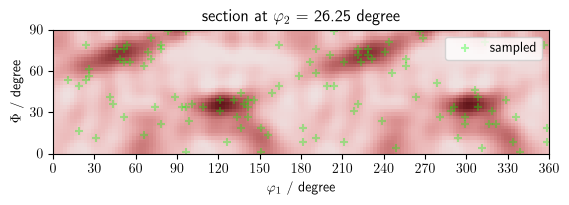

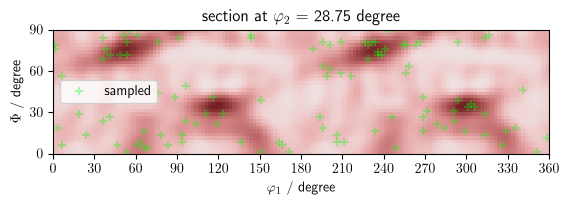

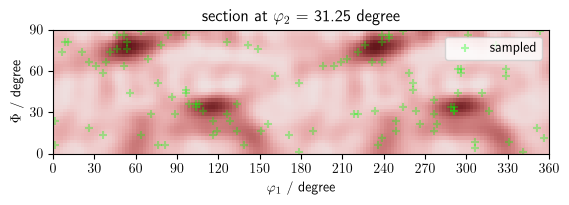

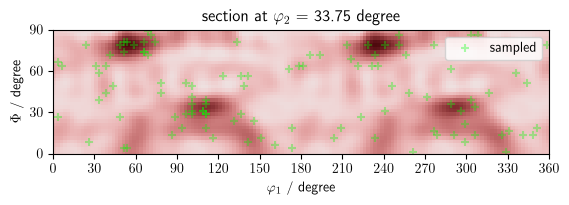

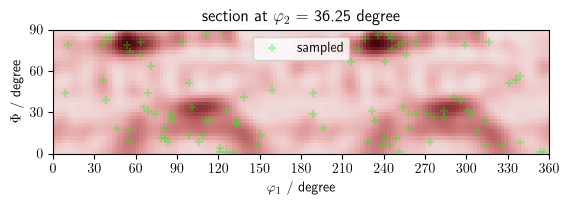

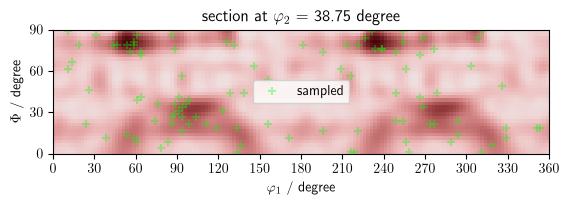

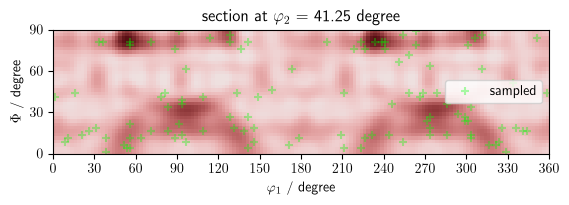

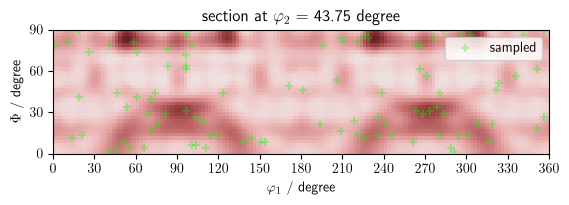

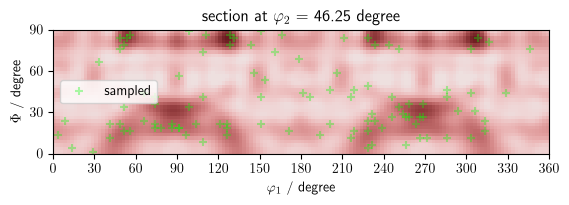

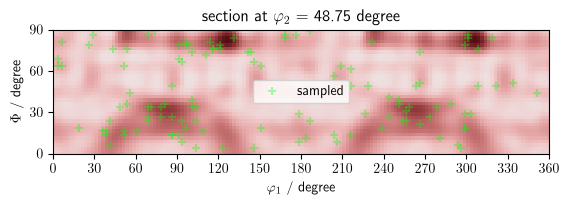

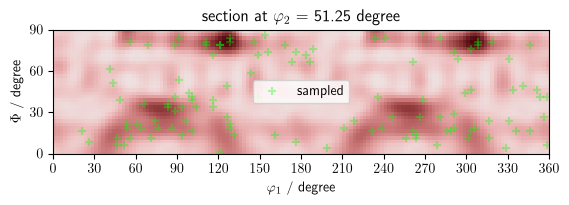

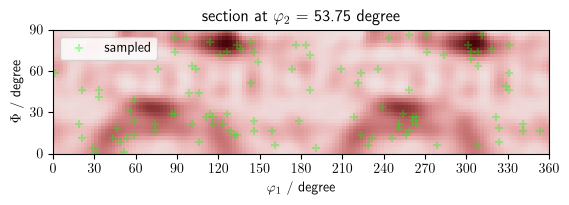

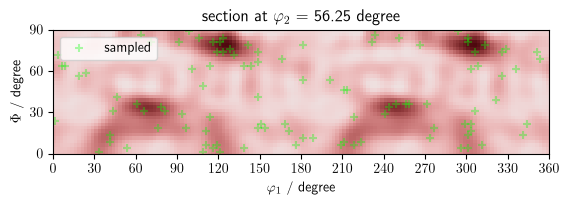

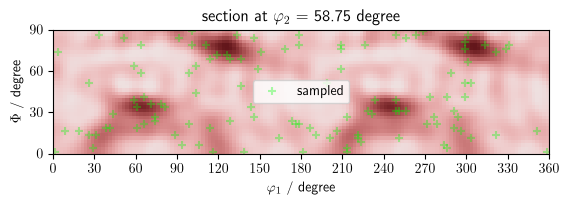

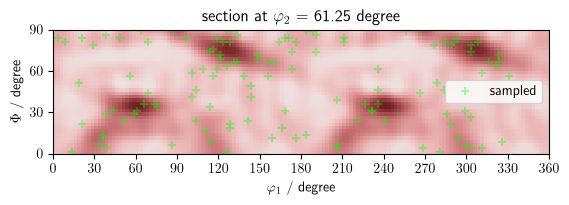

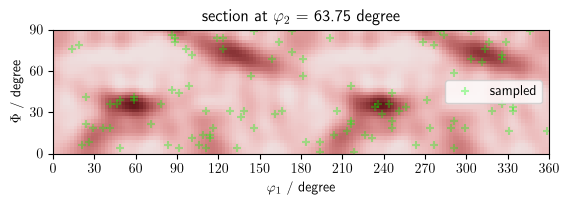

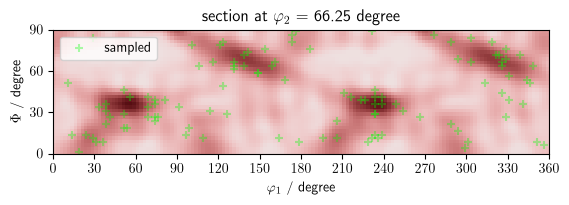

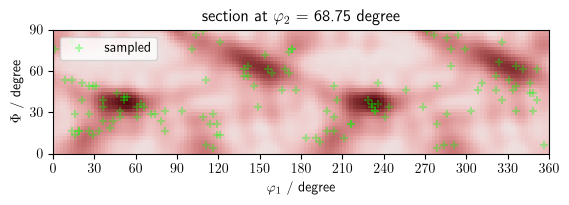

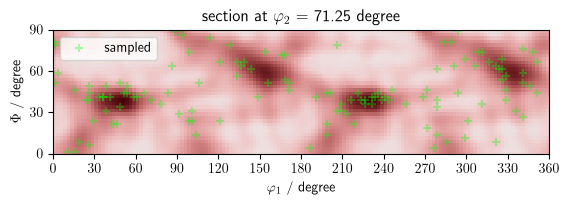

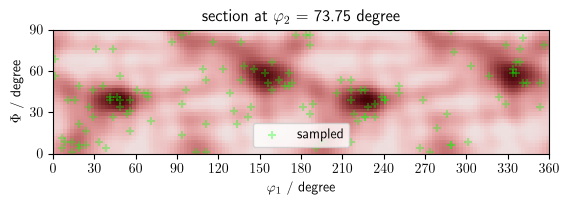

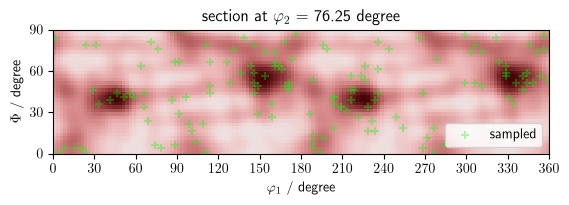

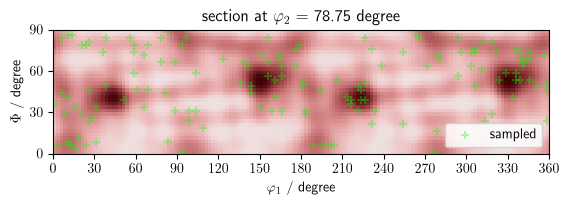

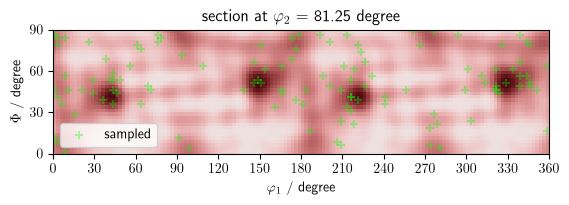

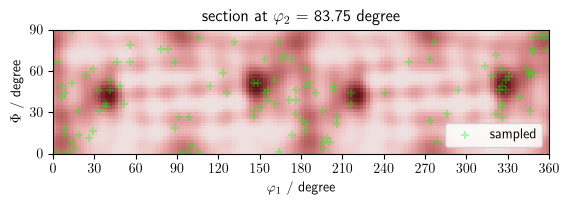

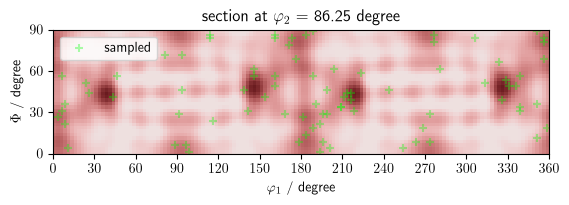

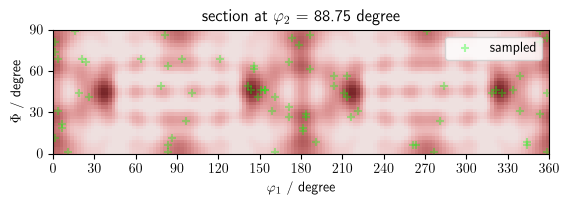

In [7]:
# visualize with matplotlib
for s,phi_2 in enumerate(np.unique(phi[:,2])):
    fig, ax = plt.subplots()
    ax.set_title(rf'section at $\varphi_2$ = {phi_2} degree')
    ax.set_ylabel(r'$\Phi$ / degree')
    ax.set_xlabel(r'$\varphi_1$ / degree')
    
    ax.set_yticks(np.linspace(0,limits[1],limits[1]//30+1,endpoint=True))
    ax.set_xticks(np.linspace(0,limits[0],limits[0]//30+1,endpoint=True))

    ax.imshow(weights.reshape(steps,order='F')[:,:,s].T,
              cmap=damask.Colormap.from_predefined('orientation'),
              interpolation='nearest',
              origin = 'lower',
              extent = [0,limits[0],0,limits[1]],
              vmin=np.min(weights),vmax=np.max(weights),
              )
    sampled_selected = sampled_eu[np.logical_and(sampled_eu[:,2] > phi_2-res/2.,
                                                 sampled_eu[:,2] < phi_2+res/2.)]
    ax.scatter(sampled_selected[:,0],sampled_selected[:,1],
               color='lime',
               marker='+',
               alpha=1/3,
               label='sampled')
    ax.legend()
    plt.show()

In [8]:
# export for visualization with ParaView
damask.VTK.from_image_data(steps,limits).set('weights',weights).save('ODF')
damask.VTK.from_poly_data(sampled_eu).save('sampled')